## Exploratory Data Analysis (EDA)

This project analyzes air quality data collected from 12 monitoring stations in Beijing, China, covering the period from 2013 to 2017. The dataset contains hourly measurements of air pollutants and meteorological conditions.

The analysis focuses on six major air pollutants: PM2.5, PM10, SO2, NO2, CO, and O3. The project examines their concentrations, distributions, changes over time, differences among monitoring stations, and relationships between pollutants.

## 1. Import Libraries

The required Python libraries are imported for data manipulation, visualization, and database connectivity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Connect to Database

Connect Python to the MySQL database containing the air quality datasets.

In [2]:
engine = create_engine(
    "mysql+pymysql://root:@localhost/air_quality"
)

try:
    with engine.connect():
        print("Connected to air_quality!")

    df = pd.read_sql_query("SELECT * FROM all_regions", engine)
    combined_df = df.copy()
    print(f"Loaded {len(df):,} records from all_regions.")
except Exception as error:
    raise RuntimeError(
        "Could not connect to MySQL or load the all_regions table. "
        "Check that MySQL is running and the air_quality database exists."
    ) from error

Connected to air_quality!
Loaded 420,768 records from all_regions.


In [3]:
combined_df.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [4]:
missing_values = combined_df.isnull().sum()

print(missing_values)

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64


## 3. Defining Pollutants

Six major air pollutants are selected for the analysis: PM2.5, PM10, SO2, NO2, CO, and O3. These variables represent different types of air pollution and are used throughout the statistical analysis and visualization sections.

In [5]:
pollutants = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
]

weather_measurements = [
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM",
]

analysis_columns = pollutants + weather_measurements
df[analysis_columns] = df[analysis_columns].apply(
    pd.to_numeric,
    errors="coerce",
)

print("Pollutants included in the analysis:")
print(pollutants)
print("Weather measurements included in the analysis:")
print(weather_measurements)

pollutant_statistics = df[pollutants].describe()
pollutant_statistics

Pollutants included in the analysis:
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
Weather measurements included in the analysis:
['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


,PM2.5,PM10,SO2,NO2,CO,O3
count,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000
mean,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271
std,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200
25%,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000
50%,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000
75%,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000
max,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000


## 4. Graph 1: Average Pollutant Concentration

The average concentration of each pollutant is calculated for every monitoring station. The visualization allows the pollutant levels to be compared across the 12 stations.

Separate graphs are used for each pollutant because the pollutants have different measurement scales and units. This makes the differences between stations easier to interpret.

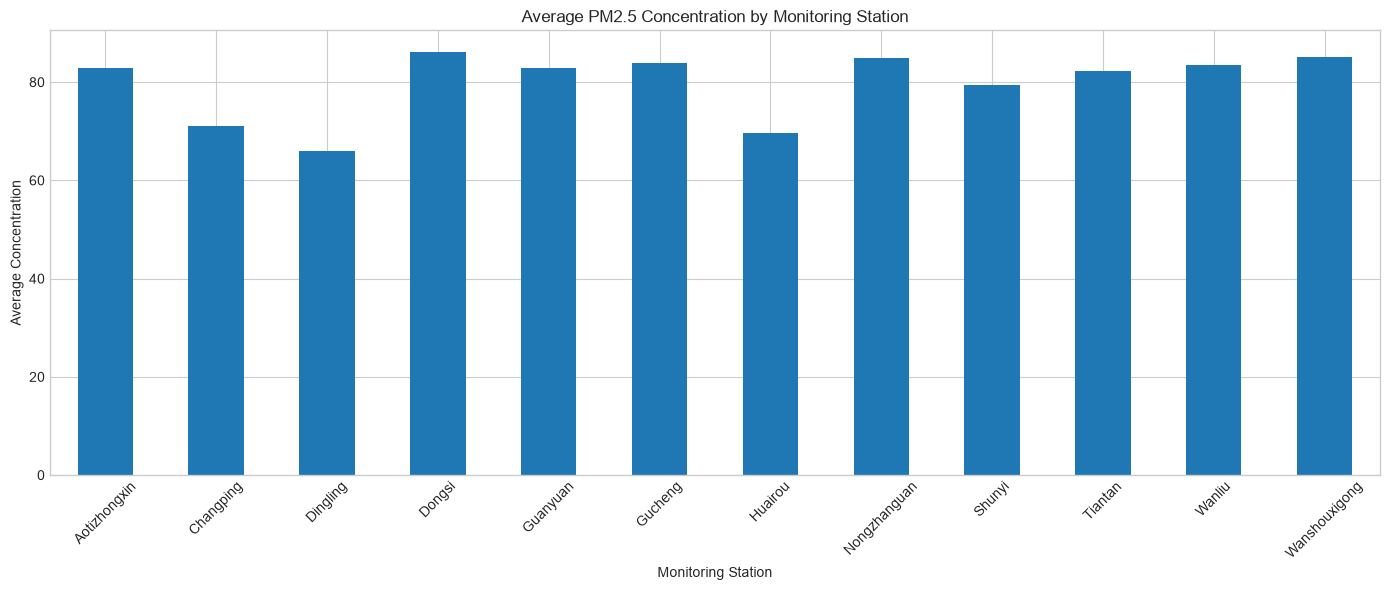

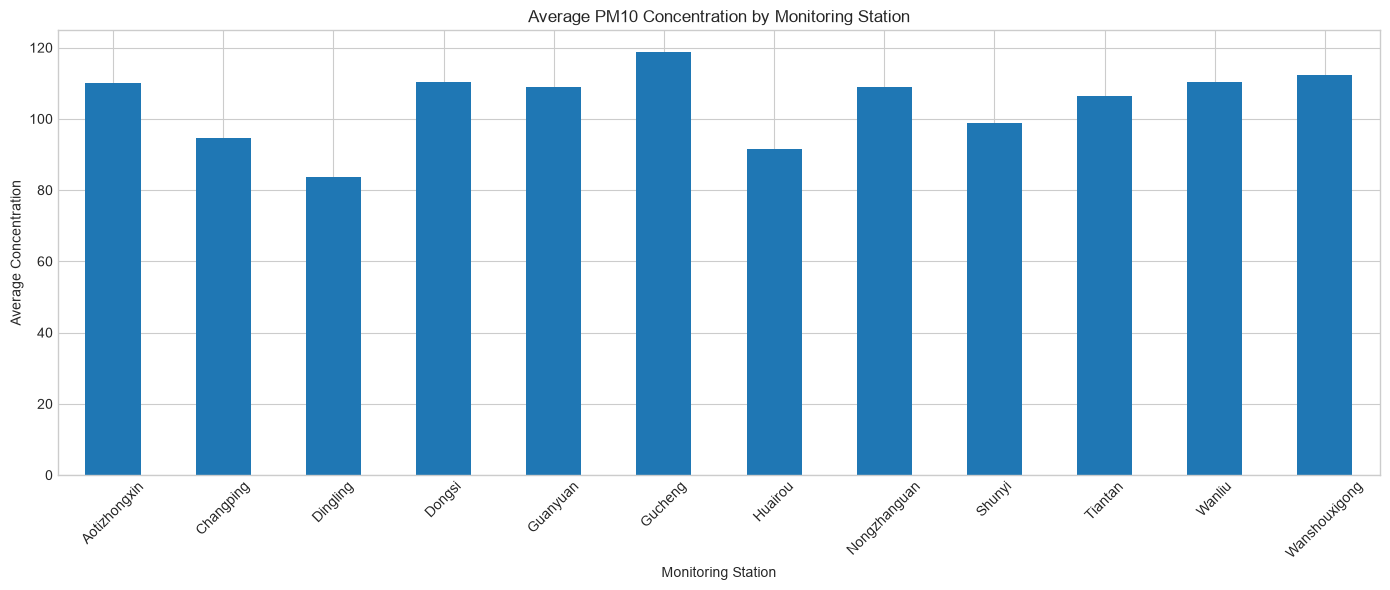

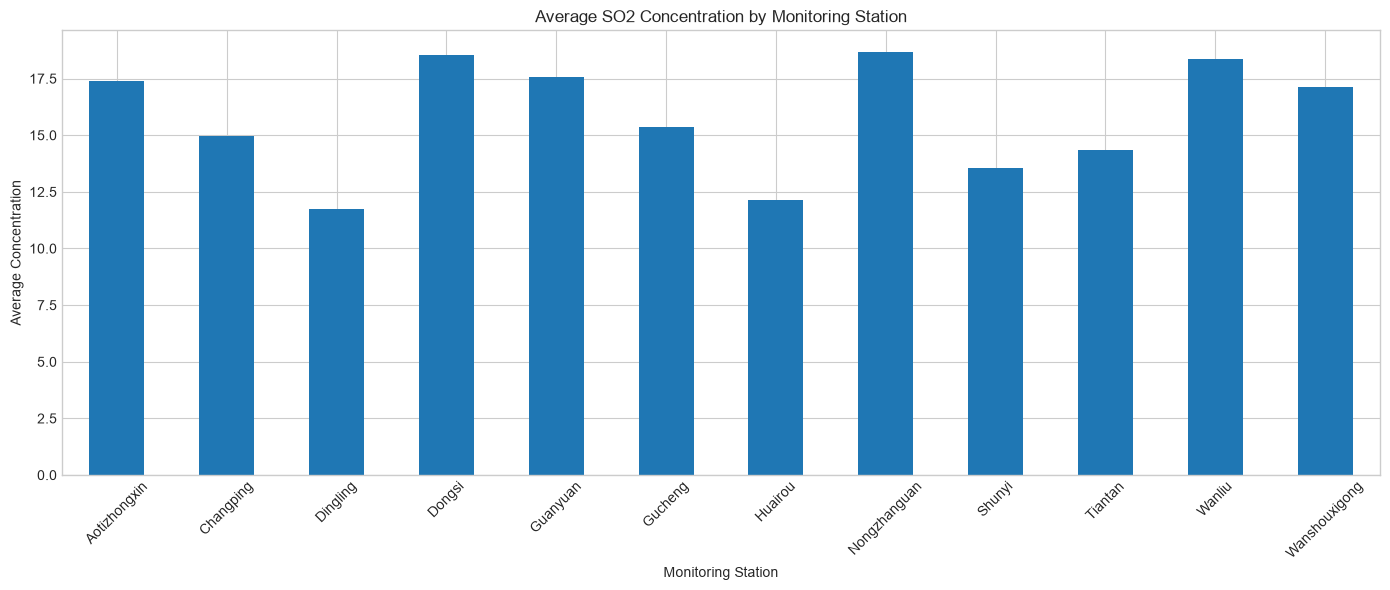

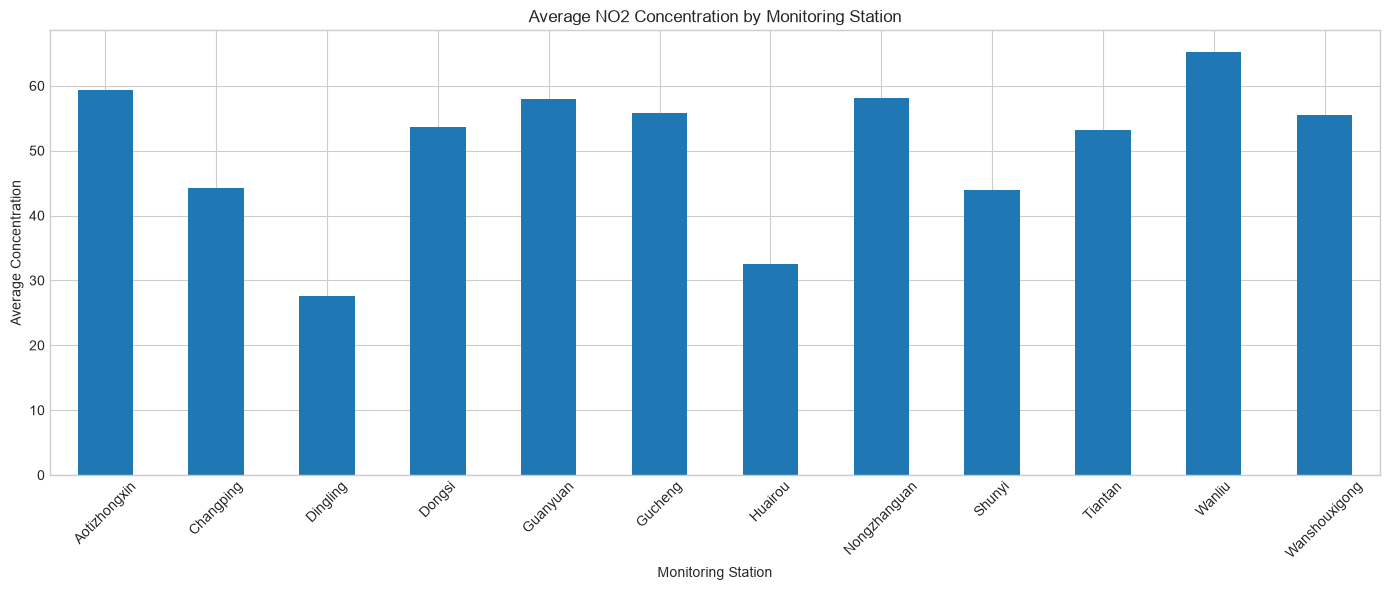

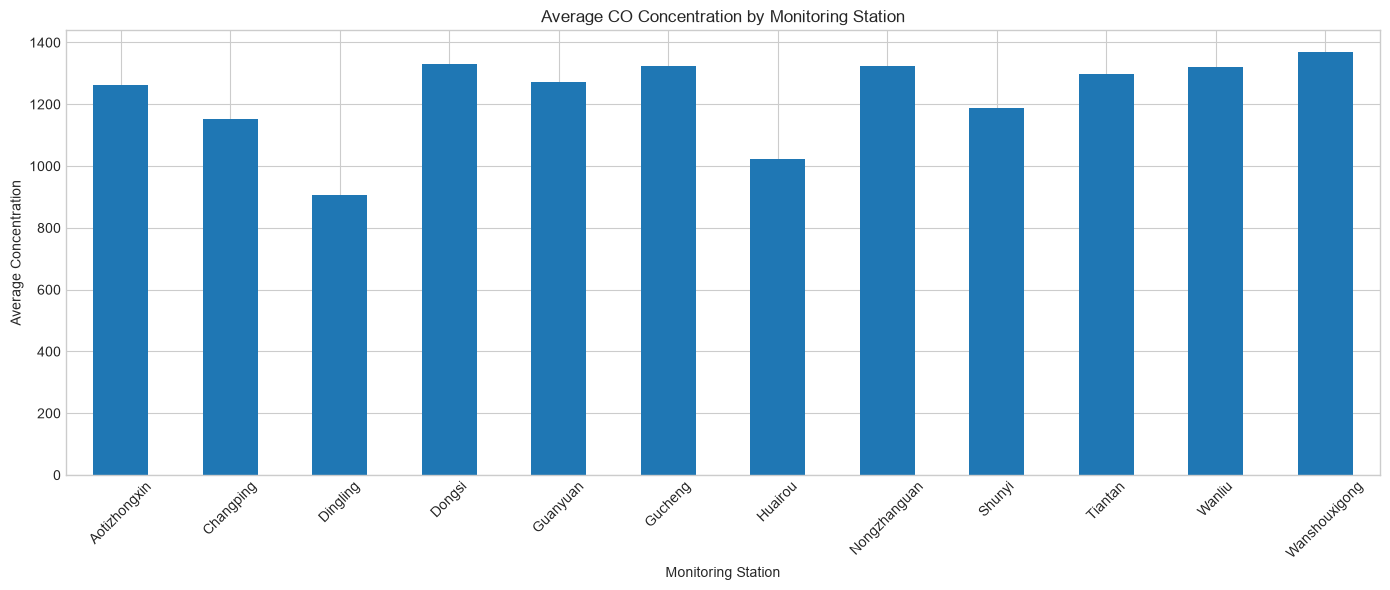

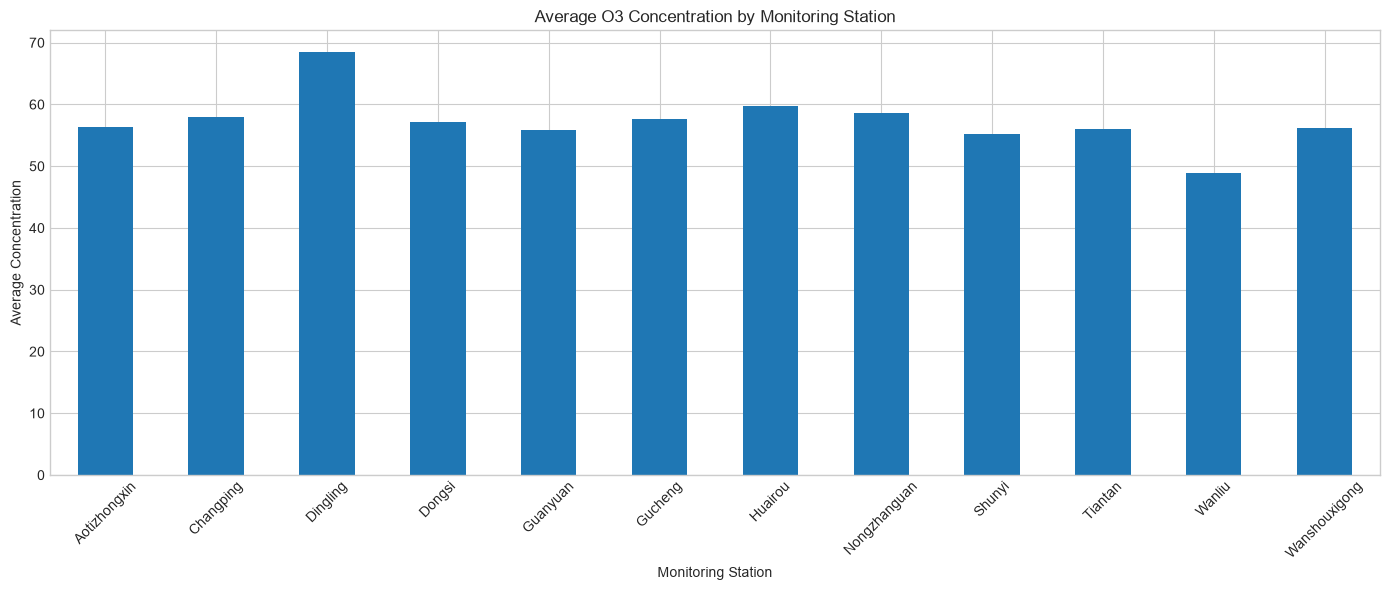

In [6]:
station_averages = combined_df.groupby("station")[pollutants].mean()

station_averages

for pollutant in pollutants:

    ax = station_averages[pollutant].plot(
        kind="bar",
        figsize=(14, 6)
    )

    ax.set_title(
        f"Average {pollutant} Concentration by Monitoring Station"
    )

    ax.set_xlabel("Monitoring Station")
    ax.set_ylabel("Average Concentration")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

In [7]:
for pollutant in pollutants:

    highest_station = station_averages[pollutant].idxmax()
    highest_value = station_averages[pollutant].max()

    lowest_station = station_averages[pollutant].idxmin()
    lowest_value = station_averages[pollutant].min()

    overall_average = station_averages[pollutant].mean()

    print(f"\n{pollutant}")
    print("=" * 50)

    print(
        f"Overall average concentration : "
        f"{overall_average:.2f}"
    )

    print(
        f"Highest average station       : "
        f"{highest_station}"
    )

    print(
        f"Highest average concentration : "
        f"{highest_value:.2f}"
    )

    print(
        f"Lowest average station        : "
        f"{lowest_station}"
    )

    print(
        f"Lowest average concentration  : "
        f"{lowest_value:.2f}"
    )


PM2.5
Overall average concentration : 79.78
Highest average station       : Dongsi
Highest average concentration : 86.19
Lowest average station        : Dingling
Lowest average concentration  : 65.99

PM10
Overall average concentration : 104.58
Highest average station       : Gucheng
Highest average concentration : 118.86
Lowest average station        : Dingling
Lowest average concentration  : 83.74

SO2
Overall average concentration : 15.82
Highest average station       : Nongzhanguan
Highest average concentration : 18.69
Lowest average station        : Dingling
Lowest average concentration  : 11.75

NO2
Overall average concentration : 50.58
Highest average station       : Wanliu
Highest average concentration : 65.26
Lowest average station        : Dingling
Lowest average concentration  : 27.59

CO
Overall average concentration : 1230.63
Highest average station       : Wanshouxigong
Highest average concentration : 1370.40
Lowest average station        : Dingling
Lowest average concen

### Analysis

The graph shows how the average concentration of the selected pollutant differs among the 12 monitoring stations. Differences between stations may indicate variations in local pollution conditions and surrounding environmental factors.

The station with the highest average value represents the location with the highest recorded average concentration for that pollutant, while the station with the lowest value represents the lowest average concentration.

## 5. Graph 2: Daily Average of Pollutants from across 12 monitoring station

Daily averages are calculated for the six pollutants using observations from the 12 monitoring stations. The graphs show how pollutant concentrations change from day to day throughout the study period.

This visualization helps identify fluctuations, periods of increased concentration, and general changes in pollutant levels over time.

In [8]:
combined_df["date"] = pd.to_datetime(
    combined_df[["year", "month", "day"]]
)

daily_pollutants = (
    combined_df
    .groupby("date")[pollutants]
    .mean()
)

daily_pollutants.head()

daily_pollutants.head()

,PM2.5,PM10,SO2,NO2,CO,O3
date,,,,,,
2013-03-01,7.326389,12.255245,9.280142,21.405738,406.737589,68.485816
2013-03-02,31.475694,40.616725,32.007989,56.704889,948.367491,32.578817
2013-03-03,79.291667,111.104167,49.386760,77.021429,1773.306620,22.788194
2013-03-04,21.731449,40.601399,18.805865,43.134273,727.923077,56.833333
2013-03-05,132.439114,159.236111,71.333333,104.256506,2047.232143,79.527778


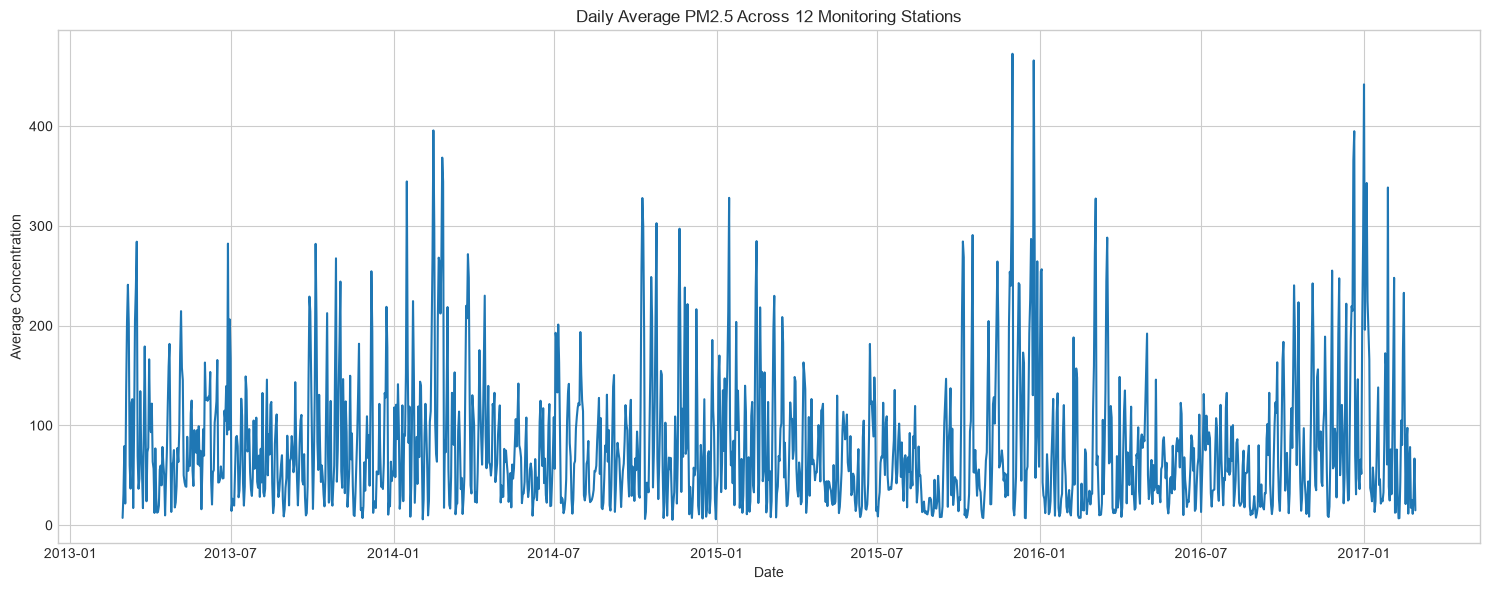

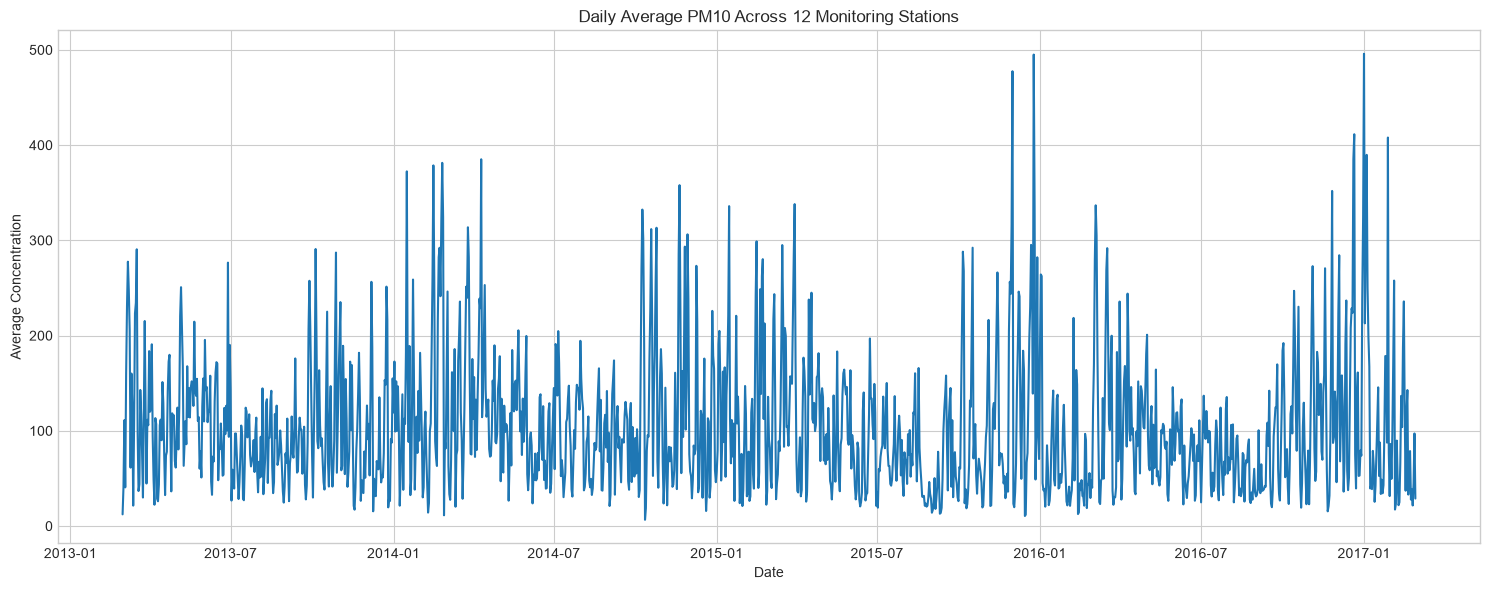

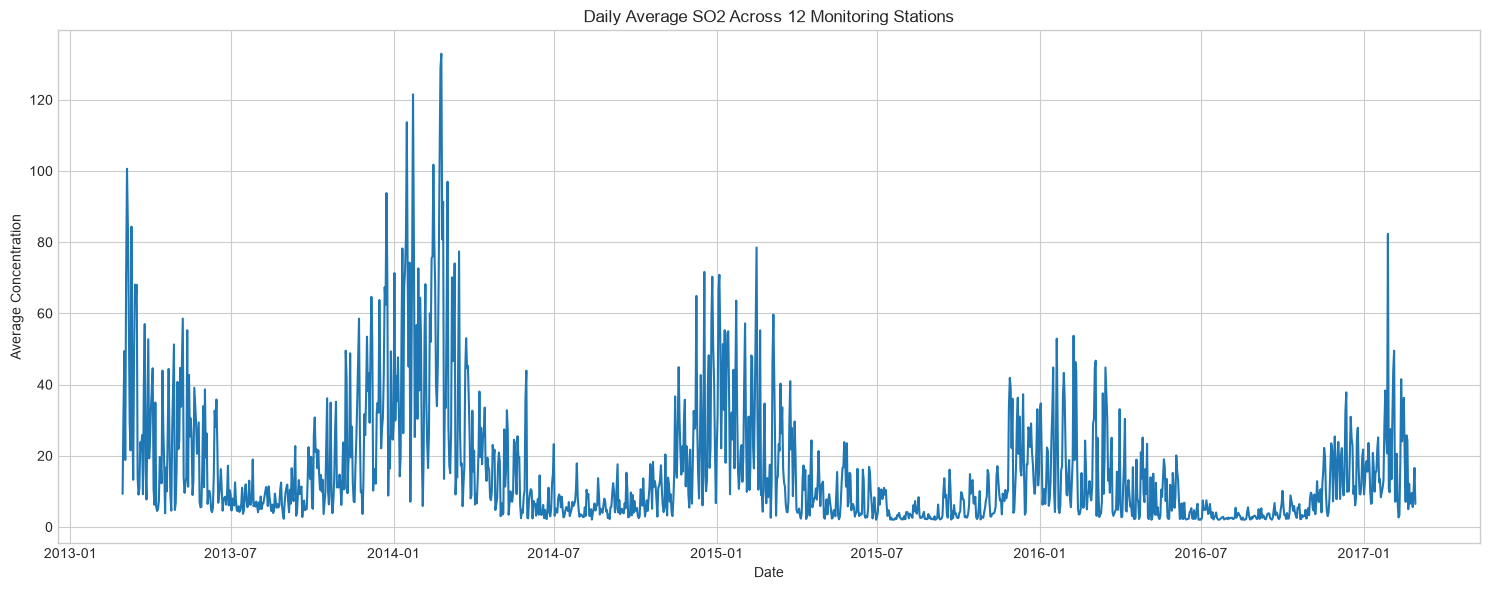

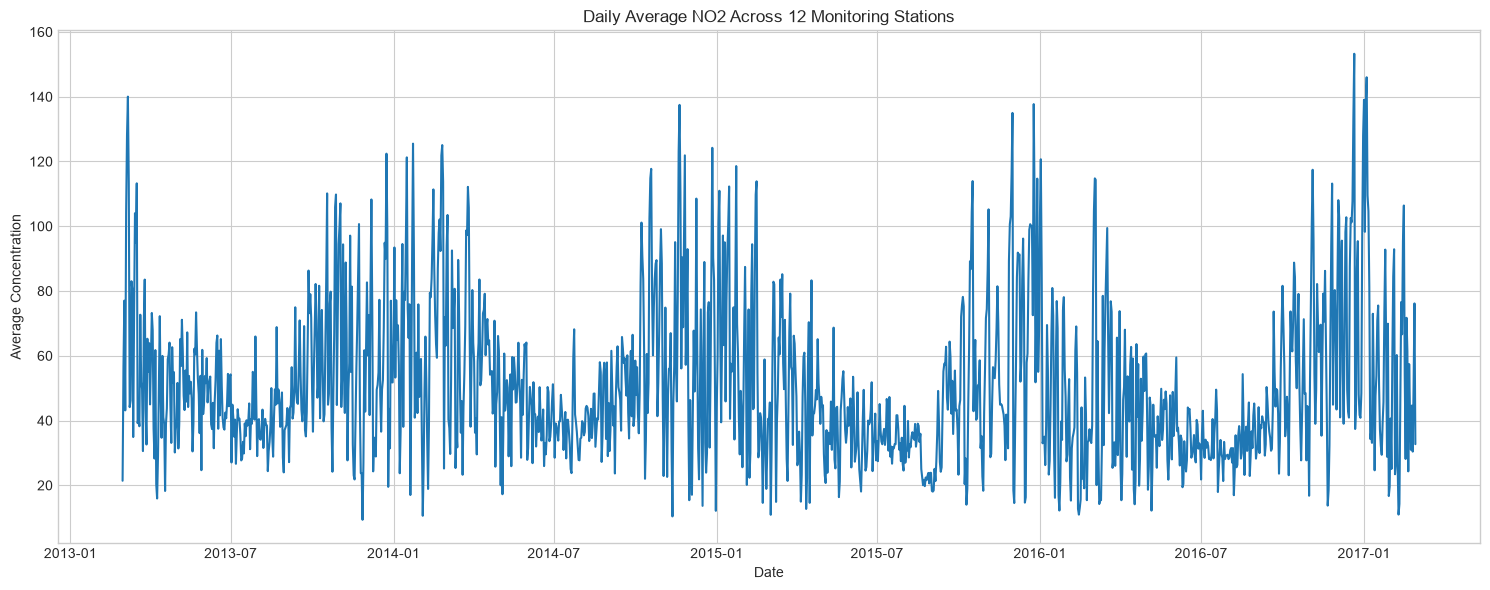

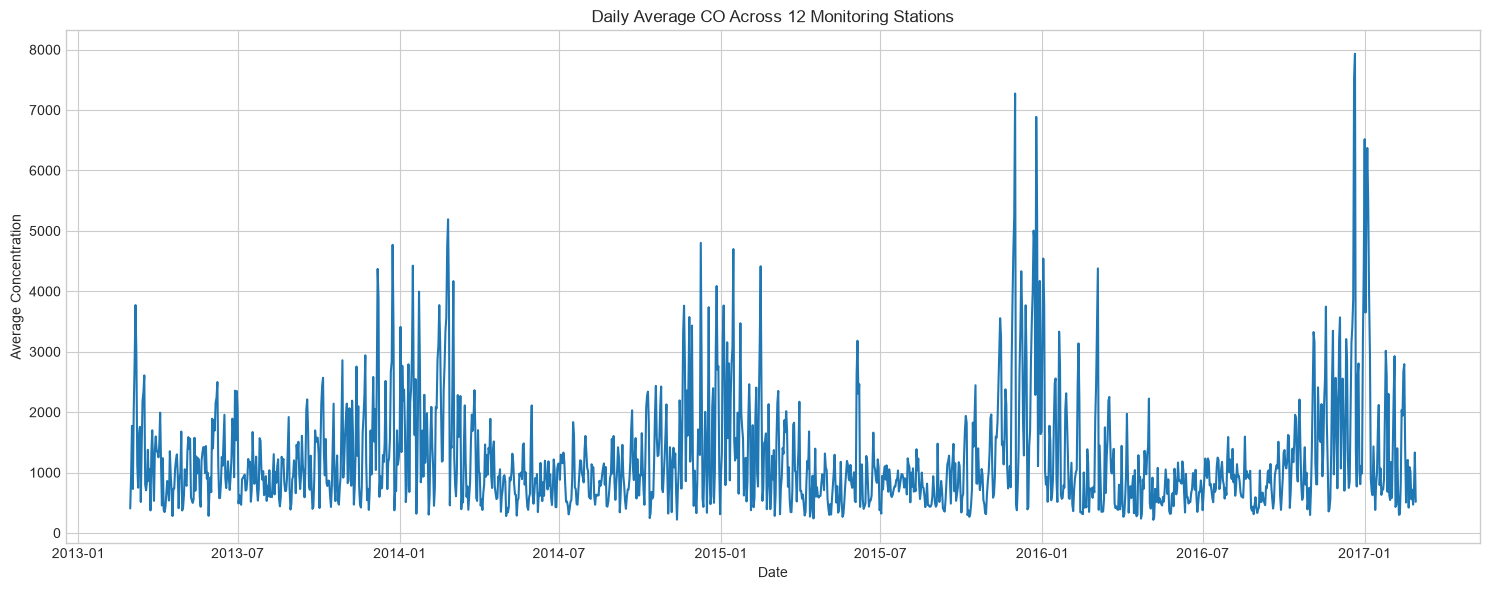

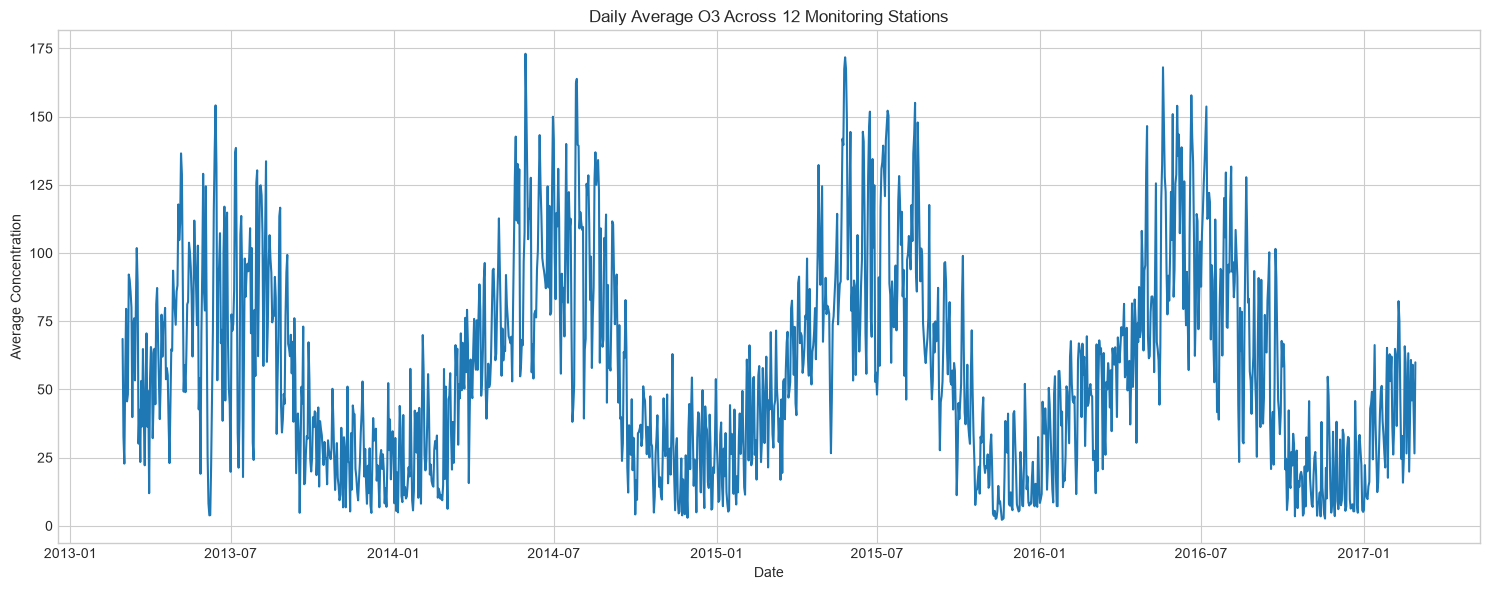

In [9]:
for pollutant in pollutants:
    plt.figure(figsize=(15, 6))
    
    plt.plot(
        daily_pollutants.index,
        daily_pollutants[pollutant]
    )
    
    plt.title(f"Daily Average {pollutant} Across 12 Monitoring Stations")
    plt.xlabel("Date")
    plt.ylabel("Average Concentration")
    plt.tight_layout()
    plt.show()

In [10]:
for pollutant in pollutants:

    daily_station = (
        combined_df
        .groupby(["date", "station"])[pollutants]
        .mean()
    )

    daily_values = daily_station[pollutant].dropna()

    highest_value = daily_values.max()
    highest_date, highest_station = daily_values.idxmax()

    lowest_value = daily_values.min()
    lowest_date, lowest_station = daily_values.idxmin()

    print(f"\n{pollutant}")
    print("=" * 50)

    print(
        f"Highest daily concentration : {highest_value:.2f}"
    )
    print(
        f"Station with highest value  : {highest_station}"
    )
    print(
        f"Date of highest value       : {highest_date.date()}"
    )

    print(
        f"Lowest daily concentration  : {lowest_value:.2f}"
    )
    print(
        f"Station with lowest value   : {lowest_station}"
    )
    print(
        f"Date of lowest value        : {lowest_date.date()}"
    )


PM2.5
Highest daily concentration : 567.42
Station with highest value  : Dongsi
Date of highest value       : 2015-12-25
Lowest daily concentration  : 3.00
Station with lowest value   : Dongsi
Date of lowest value        : 2014-10-12

PM10
Highest daily concentration : 584.67
Station with highest value  : Dongsi
Date of highest value       : 2017-01-01
Lowest daily concentration  : 4.83
Station with lowest value   : Dongsi
Date of lowest value        : 2014-10-12

SO2
Highest daily concentration : 158.32
Station with highest value  : Guanyuan
Date of highest value       : 2014-02-24
Lowest daily concentration  : 0.71
Station with lowest value   : Shunyi
Date of lowest value        : 2013-07-28

NO2
Highest daily concentration : 201.29
Station with highest value  : Wanliu
Date of highest value       : 2014-02-24
Lowest daily concentration  : 2.00
Station with lowest value   : Dingling
Date of lowest value        : 2013-11-27

CO
Highest daily concentration : 9109.09
Station with highes

### Analysis

The daily trend shows that pollutant concentrations went up and down throughout the study period. Peaks indicate periods when the average concentration increased, while lower values indicate periods of reduced concentration.

The patterns may be influenced by factors such as weather conditions, seasonal changes, and local pollution sources.

## Pollutants and Weather Measurements

This compares the linear relationships among pollutant concentrations and weather measurements.

       PM2.5   PM10    SO2    NO2     CO     O3   TEMP   PRES   DEWP   RAIN  \
PM2.5  1.000  0.884  0.482  0.667  0.790 -0.150 -0.131  0.019  0.115 -0.014   
PM10   0.884  1.000  0.463  0.652  0.702 -0.111 -0.096 -0.018  0.070 -0.027   
SO2    0.482  0.463  1.000  0.499  0.536 -0.165 -0.322  0.223 -0.267 -0.040   
NO2    0.667  0.652  0.499  1.000  0.705 -0.472 -0.278  0.174 -0.032 -0.044   
CO     0.790  0.702  0.536  0.705  1.000 -0.313 -0.326  0.188 -0.057 -0.013   
O3    -0.150 -0.111 -0.165 -0.472 -0.313  1.000  0.595 -0.446  0.312  0.023   
TEMP  -0.131 -0.096 -0.322 -0.278 -0.326  0.595  1.000 -0.813  0.820  0.038   
PRES   0.019 -0.018  0.223  0.174  0.188 -0.446 -0.813  1.000 -0.750 -0.061   
DEWP   0.115  0.070 -0.267 -0.032 -0.057  0.312  0.820 -0.750  1.000  0.086   
RAIN  -0.014 -0.027 -0.040 -0.044 -0.013  0.023  0.038 -0.061  0.086  1.000   
WSPM  -0.272 -0.184 -0.109 -0.400 -0.298  0.296  0.033  0.065 -0.297  0.021   

        WSPM  
PM2.5 -0.272  
PM10  -0.184  
SO2   

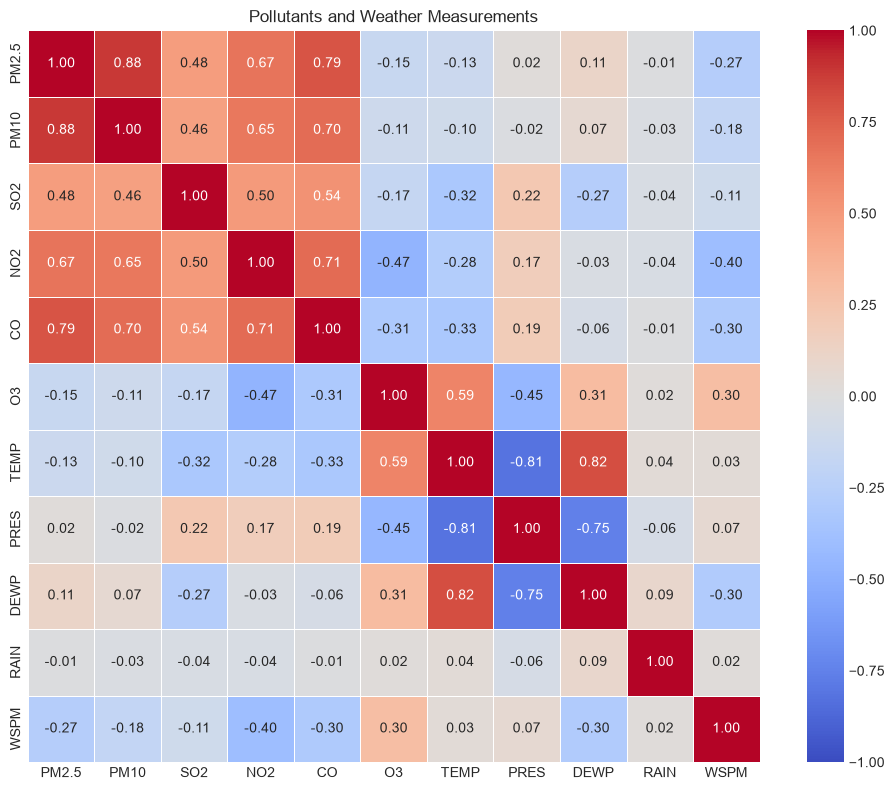

In [11]:
pearson_corr = df[analysis_columns].corr(method="pearson")
print(pearson_corr.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title("Pollutants and Weather Measurements")
plt.tight_layout()
plt.show()

### Analysis

The correlation results show that PM2.5 and PM10 increased and decreased together, with a very strong positive relationship (`r = 0.884`). PM2.5 also moved together with CO (`r = 0.790`) and NO2 (`r = 0.667`), which suggests that these pollutants may be affected by similar pollution sources or conditions.

The weather results show that temperature and dew point had a strong positive relationship (`r = 0.820`), while temperature and pressure had a strong negative relationship (`r = -0.813`). These results show that weather conditions are related to each other and may influence how pollution levels change, but correlation does not prove that one variable caused another.

## Ranked Pollutants and Weather Measurements

This compares the ranked relationships among pollutant concentrations and weather measurements.

       PM2.5   PM10    SO2    NO2     CO     O3   TEMP   PRES   DEWP   RAIN  \
PM2.5  1.000  0.891  0.500  0.658  0.837 -0.254 -0.024 -0.070  0.241 -0.020   
PM10   0.891  1.000  0.498  0.643  0.732 -0.212 -0.018 -0.077  0.150 -0.080   
SO2    0.500  0.498  1.000  0.527  0.565 -0.213 -0.360  0.291 -0.342 -0.151   
NO2    0.658  0.643  0.527  1.000  0.741 -0.614 -0.270  0.184 -0.018 -0.069   
CO     0.837  0.732  0.565  0.741  1.000 -0.450 -0.222  0.117  0.093  0.009   
O3    -0.254 -0.212 -0.213 -0.614 -0.450  1.000  0.582 -0.438  0.247 -0.010   
TEMP  -0.024 -0.018 -0.360 -0.270 -0.222  0.582  1.000 -0.819  0.817  0.039   
PRES  -0.070 -0.077  0.291  0.184  0.117 -0.438 -0.819  1.000 -0.757 -0.081   
DEWP   0.241  0.150 -0.342 -0.018  0.093  0.247  0.817 -0.757  1.000  0.177   
RAIN  -0.020 -0.080 -0.151 -0.069  0.009 -0.010  0.039 -0.081  0.177  1.000   
WSPM  -0.329 -0.251 -0.066 -0.441 -0.389  0.427  0.102  0.036 -0.237 -0.023   

        WSPM  
PM2.5 -0.329  
PM10  -0.251  
SO2   

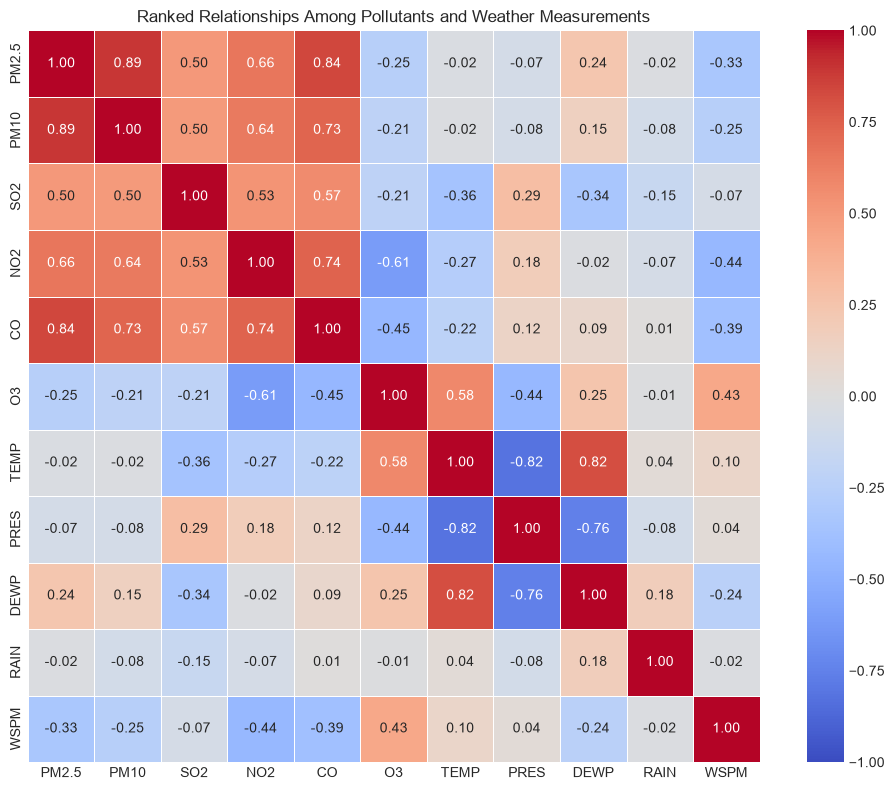

In [12]:
spearman_corr = df[analysis_columns].corr(method="spearman")
print(spearman_corr.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title("Ranked Relationships Among Pollutants and Weather Measurements")
plt.tight_layout()
plt.show()

### Analysis

The ranked correlation results show that PM2.5 and PM10 usually rise and fall together, with a very strong relationship (`rho = 0.891`). PM2.5 and CO also show a strong positive relationship (`rho = 0.837`), meaning that higher levels of one pollutant are generally associated with higher levels of the other.

NO2 and O3 generally move in opposite directions (`rho = -0.614`). Temperature and dew point move together (`rho = 0.817`), while temperature and pressure move in opposite directions (`rho = -0.819`). These results help show consistent patterns in the data, including relationships that may not be perfectly linear.

## Relationships between pollutans and weather measurements

This identifies the strongest relationships among pollutants and weather measurements.

variable_1 variable_2  correlation
     PM2.5       PM10        0.884
      TEMP       DEWP        0.820
      TEMP       PRES       -0.813
     PM2.5         CO        0.790
      PRES       DEWP       -0.750
       NO2         CO        0.705
      PM10         CO        0.702
     PM2.5        NO2        0.667
      PM10        NO2        0.652
        O3       TEMP        0.595


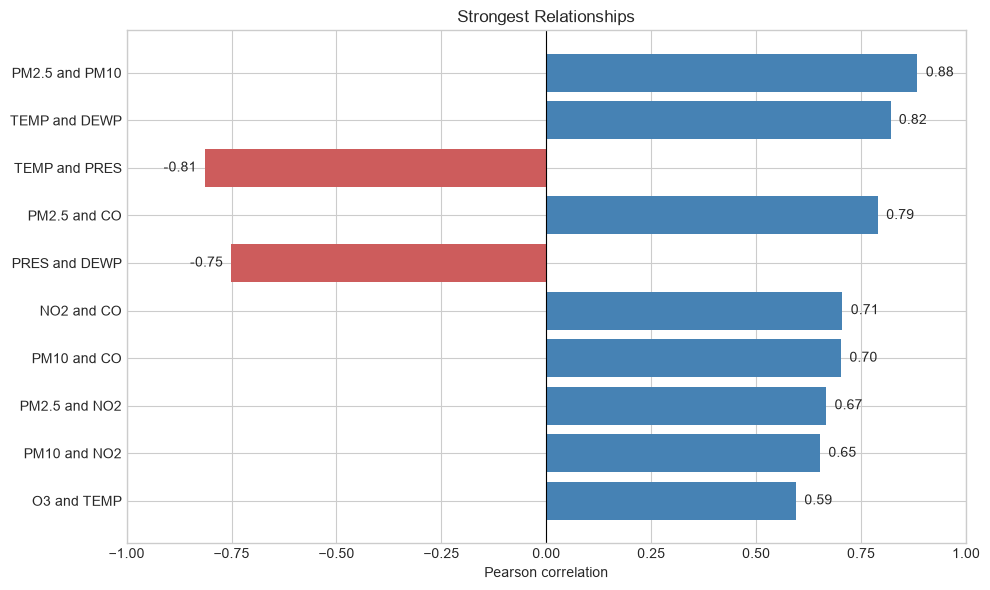

In [13]:
upper_triangle = np.triu_indices_from(pearson_corr, k=1)
strongest_pairs = pd.DataFrame({
    "variable_1": pearson_corr.index[upper_triangle[0]],
    "variable_2": pearson_corr.columns[upper_triangle[1]],
    "correlation": pearson_corr.to_numpy()[upper_triangle],
})
strongest_pairs["absolute_correlation"] = strongest_pairs["correlation"].abs()
strongest_pairs = strongest_pairs.sort_values(
    "absolute_correlation", ascending=False
).head(10)
strongest_pairs["relationship"] = (
    strongest_pairs["variable_1"] + " and " + strongest_pairs["variable_2"]
)
print(
    strongest_pairs[["variable_1", "variable_2", "correlation"]]
    .round(3)
    .to_string(index=False)
)

plt.figure(figsize=(10, 6))
colors = [
    "steelblue" if value >= 0 else "indianred"
    for value in strongest_pairs["correlation"]
]
plt.barh(
    strongest_pairs["relationship"][::-1],
    strongest_pairs["correlation"][::-1],
    color=colors[::-1],
)
plt.axvline(0, color="black", linewidth=0.8)
for index, value in enumerate(strongest_pairs["correlation"][::-1]):
    offset = 0.02 if value >= 0 else -0.02
    alignment = "left" if value >= 0 else "right"
    plt.text(
        value + offset,
        index,
        f"{value:.2f}",
        va="center",
        ha=alignment,
    )
plt.xlabel("Pearson correlation")
plt.title("Strongest Relationships")
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

### Analysis

The strongest relationships are between PM2.5 and PM10, temperature and dew point, temperature and pressure, and PM2.5 and CO. This means that particulate pollutants tend to change together, while some weather measurements also show strong connections with each other.

The PM2.5 and PM10 relationship is the most important pollution finding because both pollutants show similar increases and decreases across the dataset. The weather relationships should be interpreted as normal atmospheric patterns and should not be treated as proof that weather directly caused the pollution changes.

## PM2.5 and Other Pollutants by Station

This compares PM2.5 with the other pollutants separately for each monitoring station.

                PM10    SO2    NO2     CO     O3
station                                         
Aotizhongxin   0.879  0.481  0.685  0.785 -0.161
Changping      0.864  0.457  0.674  0.767 -0.098
Dingling       0.868  0.475  0.718  0.803 -0.101
Dongsi         0.890  0.547  0.693  0.802 -0.138
Guanyuan       0.895  0.493  0.692  0.799 -0.141
Gucheng        0.855  0.459  0.695  0.768 -0.187
Huairou        0.883  0.410  0.655  0.802 -0.064
Nongzhanguan   0.904  0.533  0.690  0.814 -0.189
Shunyi         0.900  0.462  0.644  0.782 -0.135
Tiantan        0.893  0.397  0.663  0.800 -0.167
Wanliu         0.882  0.497  0.671  0.750 -0.156
Wanshouxigong  0.890  0.502  0.697  0.814 -0.191


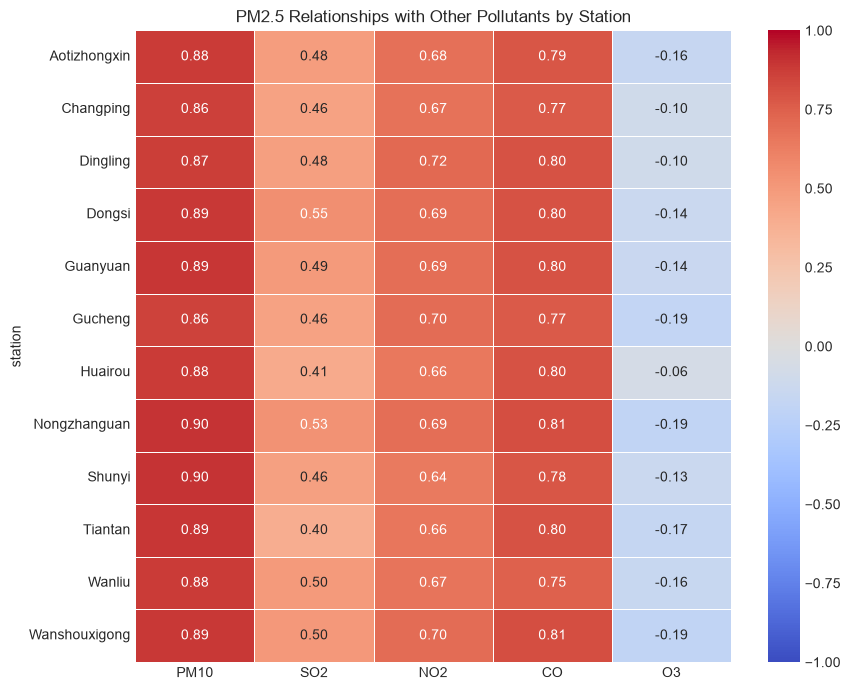

In [14]:
station_corr = (
    df.groupby("station")[pollutants]
    .corr()["PM2.5"]
    .unstack(level=1)
    .drop(columns="PM2.5")
)
print(station_corr.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(
    station_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("PM2.5 Relationships with Other Pollutants by Station")
plt.tight_layout()
plt.show()

### Analysis

The station results show that PM2.5 and PM10 had a strong positive relationship at every monitoring station, which means particulate pollution generally increased and decreased in the same way across Beijing. PM2.5 and CO also showed a strong positive relationship at all stations.

The relationship between PM2.5 and O3 was weaker and negative at every station, meaning that higher PM2.5 levels were generally associated with lower O3 levels. Although the strength of the relationships changed slightly between stations, the overall pollution pattern was similar across the monitoring network.